# Heart Disease Prediction

Predicting heart disease from clinical data using machine learning. The dataset combines records from 5 sources — 918 patients, 11 features covering demographics, blood tests, and ECG readings.

**Objectives:**
1. Feature importance analysis — which clinical factors matter most?
2. Correlation analysis — how do features relate to heart disease?
3. Patient stratification — how does risk vary by age, gender, and exercise?
4. Random Forest model for predicting fasting blood sugar
5. Comparative analysis — Decision Tree vs Random Forest vs Gradient Boosting

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)
from scipy.stats import pearsonr

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.grid': True, 'grid.alpha': 0.3})

# Load data
df = pd.read_csv('heart.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [2]:
# Quick overview
print('Data types:')
print(df.dtypes)
print(f'\nMissing values: {df.isnull().sum().sum()}')
print(f'\nTarget distribution:')
print(df['HeartDisease'].value_counts())
print(f'\nDefault rate: {df["HeartDisease"].mean():.1%}')

Data types:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

Missing values: 0

Target distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64

Default rate: 55.3%


In [3]:
# Preprocessing — encode categorical columns
# We need numeric features for correlation analysis and ML models

def preprocess_data(data):
    data = data.copy()
    le = LabelEncoder()
    categorical_cols = data.select_dtypes(exclude=['number']).columns
    for col in categorical_cols:
        data[col] = le.fit_transform(data[col])
    return data

df_encoded = preprocess_data(df)
print('Encoding complete. All columns now numeric.')
df_encoded.head()

Encoding complete. All columns now numeric.


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


## Objective 1 — Feature Importance Analysis

Using a Decision Tree to rank which features contribute most to predicting heart disease.

In [4]:
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

dt_importance = DecisionTreeClassifier(random_state=42)
dt_importance.fit(X, y)

feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_importance.feature_importances_
}).sort_values('Importance', ascending=False)

print('Feature Importances:')
print(feature_importances.to_string(index=False))

Feature Importances:
       Feature  Importance
      ST_Slope    0.398510
   Cholesterol    0.123209
         MaxHR    0.083945
 ChestPainType    0.080916
           Age    0.076163
       Oldpeak    0.072638
     RestingBP    0.057146
           Sex    0.035998
ExerciseAngina    0.025193
     FastingBS    0.023833
    RestingECG    0.022448


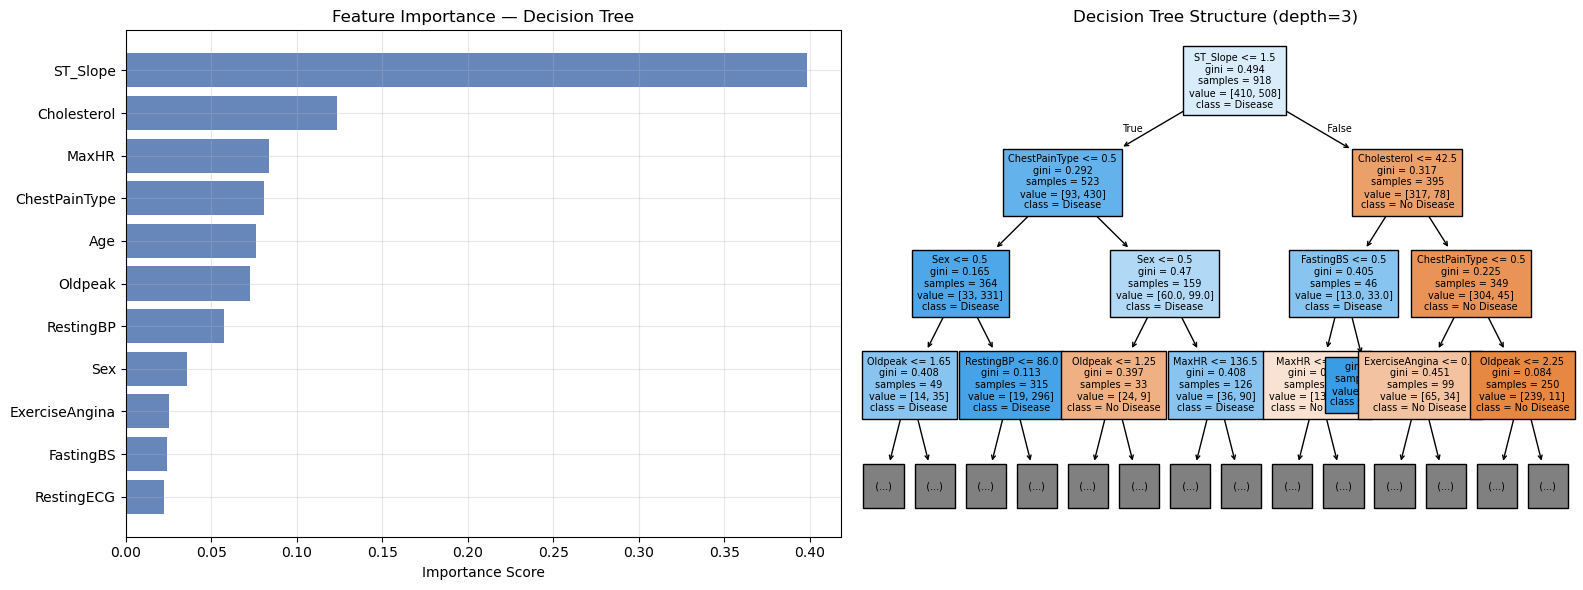


Top feature: ST_Slope (0.399)


In [5]:
# Visualise feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
fi_sorted = feature_importances.sort_values('Importance', ascending=True)
axes[0].barh(fi_sorted['Feature'], fi_sorted['Importance'], color='#4C72B0', alpha=0.85)
axes[0].set_xlabel('Importance Score')
axes[0].set_title('Feature Importance — Decision Tree')

# Decision tree structure (limited depth for readability)
plot_tree(dt_importance, feature_names=X.columns, class_names=['No Disease', 'Disease'],
          filled=True, max_depth=3, ax=axes[1], fontsize=7)
axes[1].set_title('Decision Tree Structure (depth=3)')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTop feature: {feature_importances.iloc[0]["Feature"]} ({feature_importances.iloc[0]["Importance"]:.3f})')

## Objective 2 — Correlation Analysis

Exploring relationships between features and heart disease. Also testing statistical significance of the strongest correlation.

In [6]:
# Correlation with target
correlation_matrix = df_encoded.corr()
target_corr = correlation_matrix['HeartDisease'].sort_values(ascending=False)

print('Correlation with HeartDisease:')
print(target_corr.to_string())

Correlation with HeartDisease:
HeartDisease      1.000000
ExerciseAngina    0.494282
Oldpeak           0.403951
Sex               0.305445
Age               0.282039
FastingBS         0.267291
RestingBP         0.107589
RestingECG        0.057384
Cholesterol      -0.232741
ChestPainType    -0.386828
MaxHR            -0.400421
ST_Slope         -0.558771


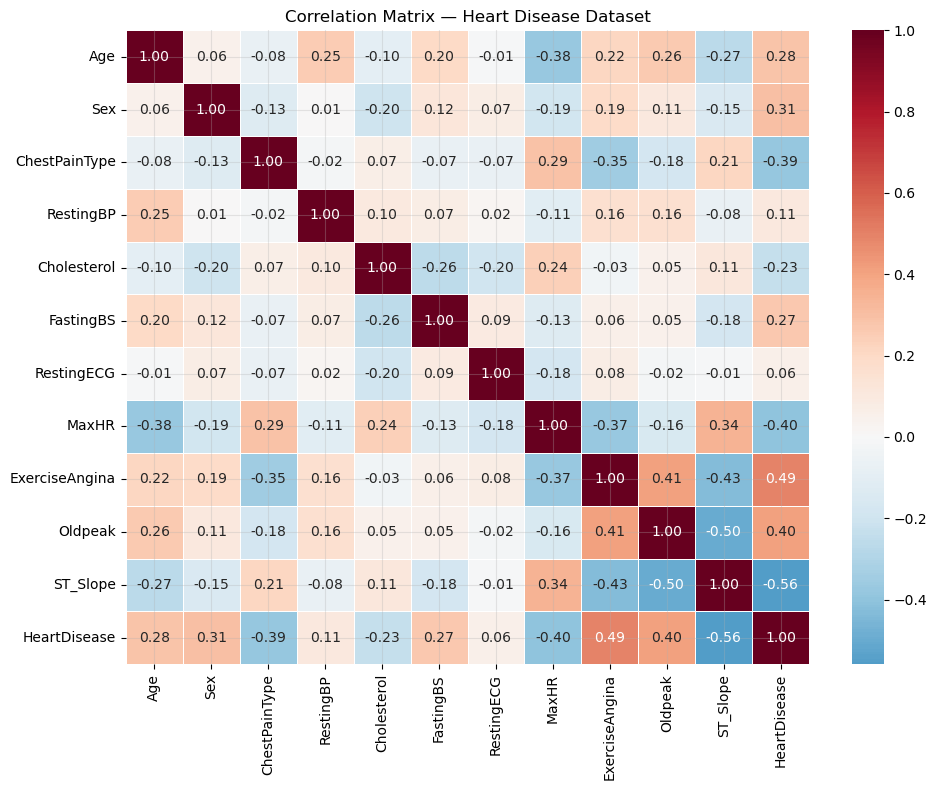

In [7]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5)
plt.title('Correlation Matrix — Heart Disease Dataset')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Statistical significance test for ExerciseAngina vs HeartDisease
corr_coef, p_value = pearsonr(df_encoded['ExerciseAngina'], df_encoded['HeartDisease'])
print(f'ExerciseAngina vs HeartDisease:')
print(f'  Correlation coefficient: {corr_coef:.4f}')
print(f'  P-value: {p_value:.6f}')
print(f'  Statistically significant: {"Yes" if p_value < 0.05 else "No"} (p < 0.05)')

ExerciseAngina vs HeartDisease:
  Correlation coefficient: 0.4943
  P-value: 0.000000
  Statistically significant: Yes (p < 0.05)


## Objective 3 — Patient Stratification

How does heart disease prevalence vary across age groups, gender, and exercise-induced angina?

In [9]:
# Age stratification
age_bins = [25, 30, 40, 50, 60, 80, float('inf')]
age_labels = ['25-30', '31-40', '41-50', '51-60', '61-80', '80+']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=True)

HDisease_count_Age = df.groupby('AgeGroup', observed=True)['HeartDisease'].value_counts().unstack(fill_value=0)
HDisease_count_gender = df.groupby('Sex')['HeartDisease'].value_counts().unstack(fill_value=0)
HDisease_count_exercise = df.groupby('ExerciseAngina')['HeartDisease'].value_counts().unstack(fill_value=0)

print('Heart Disease by Age Group:')
print(HDisease_count_Age)
print('\nHeart Disease by Gender:')
print(HDisease_count_gender)
print('\nHeart Disease by Exercise Angina:')
print(HDisease_count_exercise)

Heart Disease by Age Group:
HeartDisease    0    1
AgeGroup              
25-30           5    0
31-40          56   32
41-50         130   93
51-60         159  222
61-80          60  161

Heart Disease by Gender:
HeartDisease    0    1
Sex                   
F             143   50
M             267  458

Heart Disease by Exercise Angina:
HeartDisease      0    1
ExerciseAngina          
N               355  192
Y                55  316


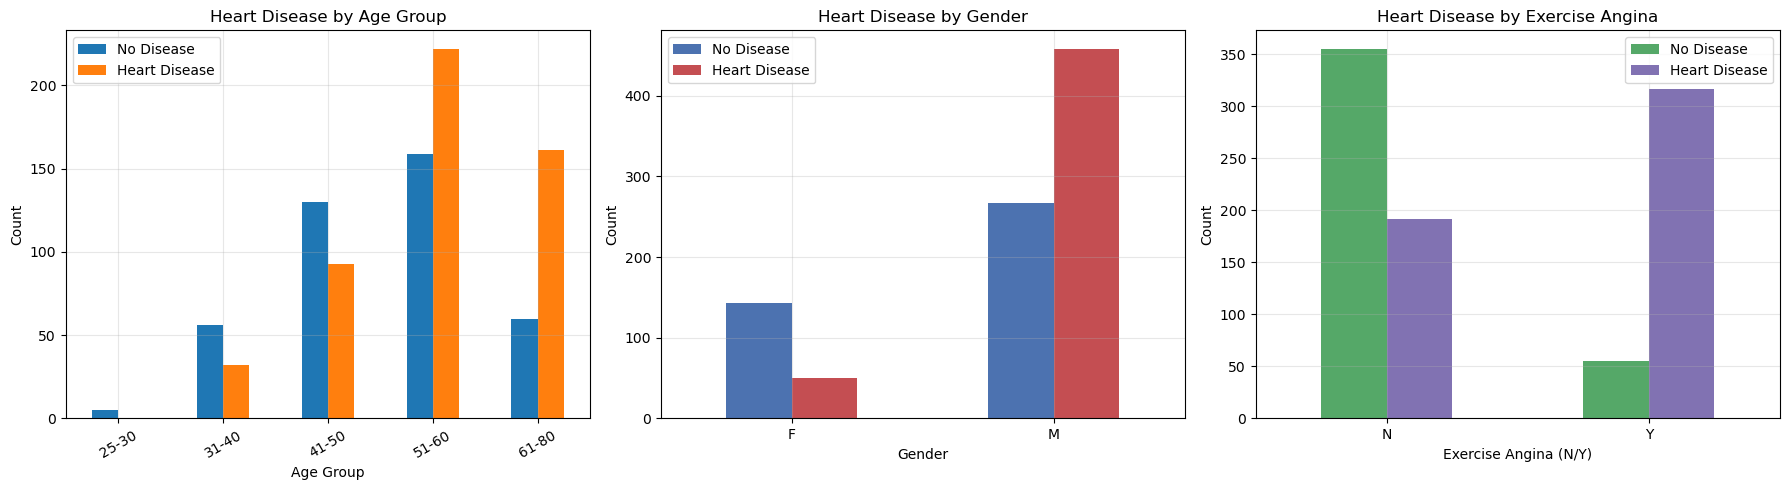

In [10]:
# Visualise stratification
fig, (axis_age, axis_gender, axis_exercise) = plt.subplots(1, 3, figsize=(18, 5))

HDisease_count_Age.plot(kind='bar', stacked=False, ax=axis_age)
axis_age.set_title('Heart Disease by Age Group')
axis_age.set_xlabel('Age Group')
axis_age.set_ylabel('Count')
axis_age.legend(['No Disease', 'Heart Disease'])
axis_age.tick_params(axis='x', rotation=30)

HDisease_count_gender.plot(kind='bar', stacked=False, color=['#4C72B0', '#C44E52'], ax=axis_gender)
axis_gender.set_title('Heart Disease by Gender')
axis_gender.set_xlabel('Gender')
axis_gender.set_ylabel('Count')
axis_gender.legend(['No Disease', 'Heart Disease'])
axis_gender.tick_params(axis='x', rotation=0)

HDisease_count_exercise.plot(kind='bar', stacked=False, color=['#55A868', '#8172B2'], ax=axis_exercise)
axis_exercise.set_title('Heart Disease by Exercise Angina')
axis_exercise.set_xlabel('Exercise Angina (N/Y)')
axis_exercise.set_ylabel('Count')
axis_exercise.legend(['No Disease', 'Heart Disease'])
axis_exercise.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('patient_stratification.png', dpi=150, bbox_inches='tight')
plt.show()

## Objective 4 — Random Forest: Predicting Fasting Blood Sugar

Using numerical features to predict whether a patient has high fasting blood sugar (FastingBS = 1 means > 120 mg/dl).

In [11]:
# Use only numerical features for this objective
numerical_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease']
target_col = 'FastingBS'

X_fbs = df[numerical_features]
y_fbs = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X_fbs, y_fbs, test_size=0.2, random_state=42, stratify=y_fbs
)

rf_acc = RandomForestClassifier(n_estimators=100, random_state=42)
rf_acc.fit(X_train, y_train)

y_pred_fbs = rf_acc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_fbs)

print(f'Random Forest Accuracy (predicting FastingBS): {accuracy:.3f} ({accuracy*100:.1f}%)')
print()
print(classification_report(y_test, y_pred_fbs, target_names=['Normal BS', 'High BS']))

Random Forest Accuracy (predicting FastingBS): 0.777 (77.7%)

              precision    recall  f1-score   support

   Normal BS       0.81      0.93      0.86       141
     High BS       0.55      0.28      0.37        43

    accuracy                           0.78       184
   macro avg       0.68      0.60      0.62       184
weighted avg       0.75      0.78      0.75       184



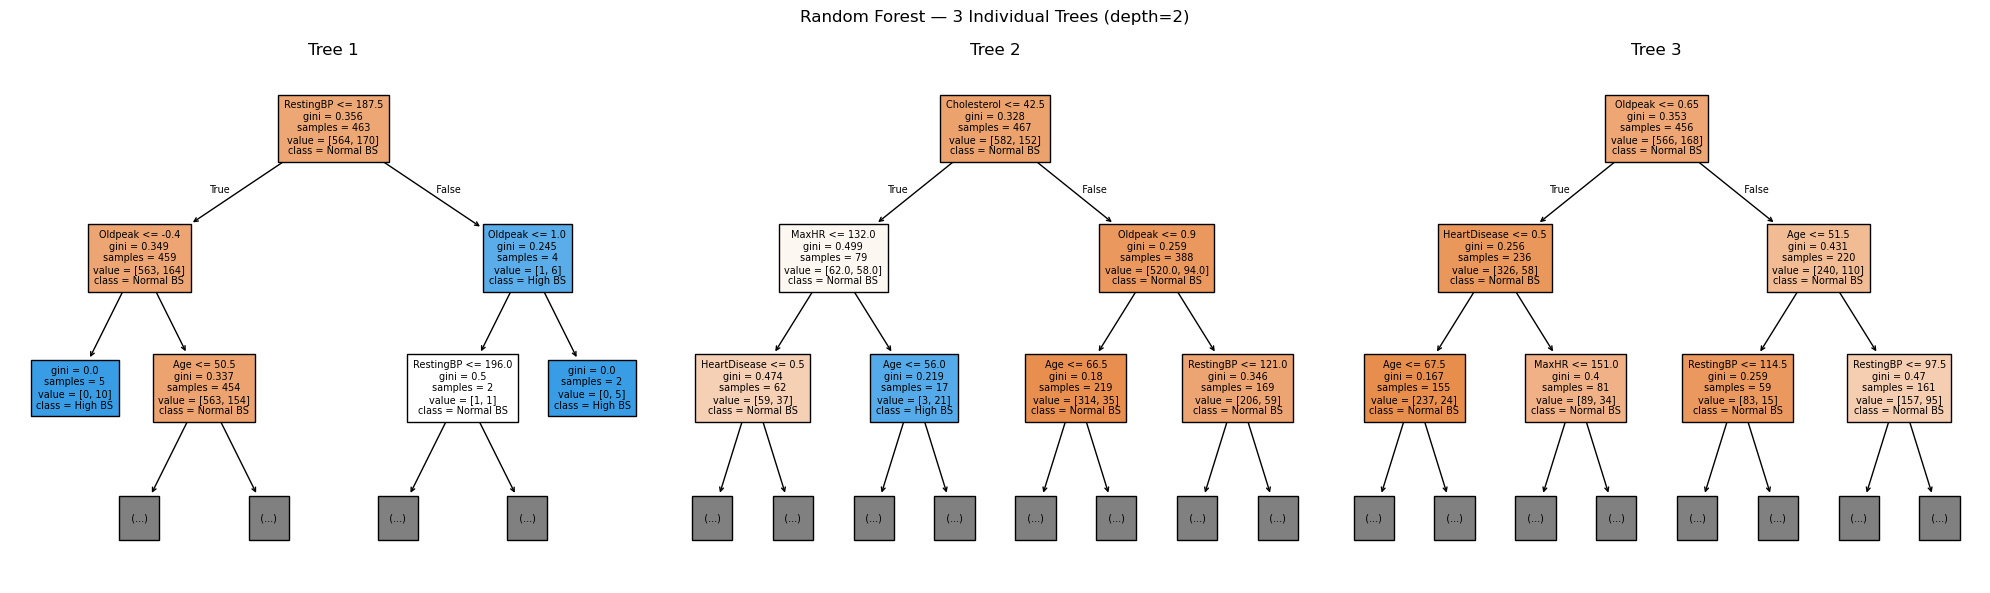

In [12]:
# Visualise 3 individual trees from the Random Forest
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, ax in enumerate(axes):
    plot_tree(
        rf_acc.estimators_[i],
        feature_names=X_train.columns,
        class_names=['Normal BS', 'High BS'],
        filled=True, max_depth=2, ax=ax, fontsize=7
    )
    ax.set_title(f'Tree {i+1}')

plt.suptitle('Random Forest — 3 Individual Trees (depth=2)', fontsize=12)
plt.tight_layout()
plt.savefig('random_forest_trees.png', dpi=150, bbox_inches='tight')
plt.show()

## Objective 5 — Comparative Analysis: DT vs RF vs Gradient Boosting

Comparing all three models for predicting heart disease. Metrics: accuracy, precision, recall, F1, ROC-AUC.

In [13]:
# Prepare data — all features, HeartDisease as target
X_all = df_encoded.drop('HeartDisease', axis=1)
y_all = df_encoded['HeartDisease']

x_train, x_test, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print(f'Train: {len(x_train)} | Test: {len(x_test)}')
print(f'Heart disease rate in test set: {y_test_all.mean():.1%}')

Train: 734 | Test: 184
Heart disease rate in test set: 55.4%


In [14]:
# Train all 3 models
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train_all)
y_pred_dt = dt.predict(x_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train_all)
y_pred_rf = rf.predict(x_test)

gbc = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbc.fit(x_train, y_train_all)
y_pred_gbc = gbc.predict(x_test)

# Accuracy comparison
acc_dt  = accuracy_score(y_test_all, y_pred_dt)
acc_rf  = accuracy_score(y_test_all, y_pred_rf)
acc_gbc = accuracy_score(y_test_all, y_pred_gbc)

print(f'Decision Tree:      {acc_dt:.4f} ({acc_dt*100:.1f}%)')
print(f'Random Forest:      {acc_rf:.4f} ({acc_rf*100:.1f}%)')
print(f'Gradient Boosting:  {acc_gbc:.4f} ({acc_gbc*100:.1f}%)')

Decision Tree:      0.7880 (78.8%)
Random Forest:      0.8750 (87.5%)
Gradient Boosting:  0.8859 (88.6%)


In [15]:
# Full metrics for each model
for name, y_pred in [('Decision Tree', y_pred_dt),
                      ('Random Forest', y_pred_rf),
                      ('Gradient Boosting', y_pred_gbc)]:
    print(f'\n=== {name} ===')
    print(classification_report(y_test_all, y_pred, target_names=['No Disease', 'Heart Disease']))


=== Decision Tree ===
               precision    recall  f1-score   support

   No Disease       0.76      0.77      0.76        82
Heart Disease       0.81      0.80      0.81       102

     accuracy                           0.79       184
    macro avg       0.79      0.79      0.79       184
 weighted avg       0.79      0.79      0.79       184


=== Random Forest ===
               precision    recall  f1-score   support

   No Disease       0.87      0.84      0.86        82
Heart Disease       0.88      0.90      0.89       102

     accuracy                           0.88       184
    macro avg       0.87      0.87      0.87       184
 weighted avg       0.87      0.88      0.87       184


=== Gradient Boosting ===
               precision    recall  f1-score   support

   No Disease       0.87      0.88      0.87        82
Heart Disease       0.90      0.89      0.90       102

     accuracy                           0.89       184
    macro avg       0.88      0.89     

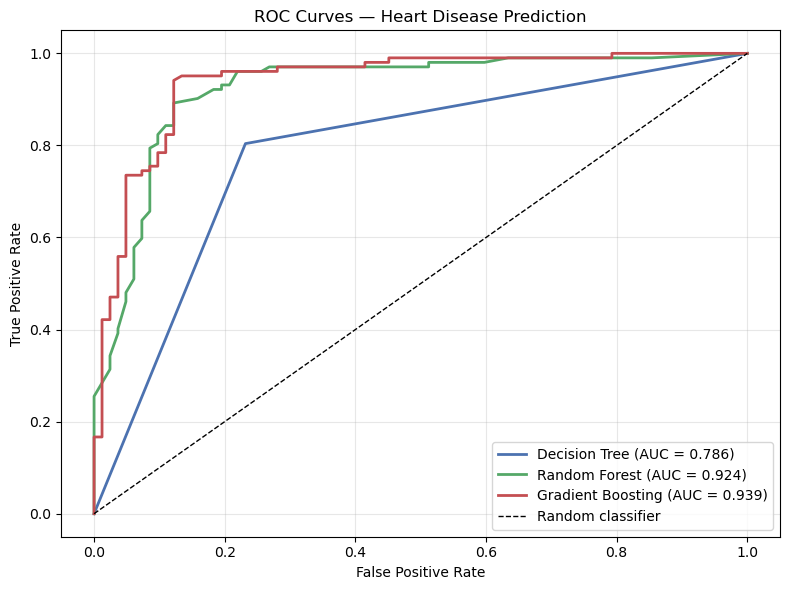

In [16]:
# ROC Curves
models = [('Decision Tree', dt), ('Random Forest', rf), ('Gradient Boosting', gbc)]
colors = ['#4C72B0', '#55A868', '#C44E52']

plt.figure(figsize=(8, 6))
for (name, model), color in zip(models, colors):
    y_prob = model.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_all, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Heart Disease Prediction')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

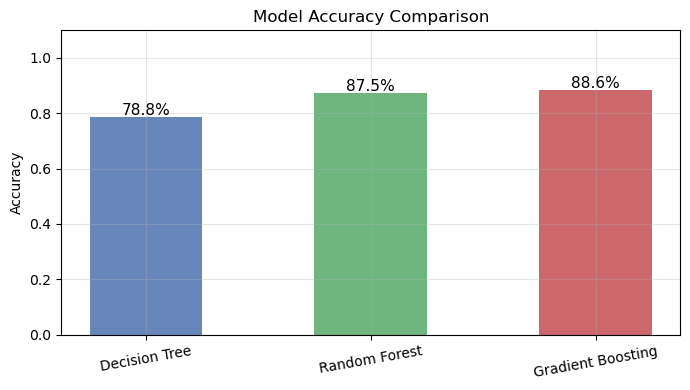

In [17]:
# Accuracy comparison bar chart
accuracy_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [acc_dt, acc_rf, acc_gbc]
})

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(accuracy_df['Model'], accuracy_df['Accuracy'],
              color=['#4C72B0', '#55A868', '#C44E52'], alpha=0.85, width=0.5)
for bar, val in zip(bars, accuracy_df['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.1%}', ha='center', fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison')
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

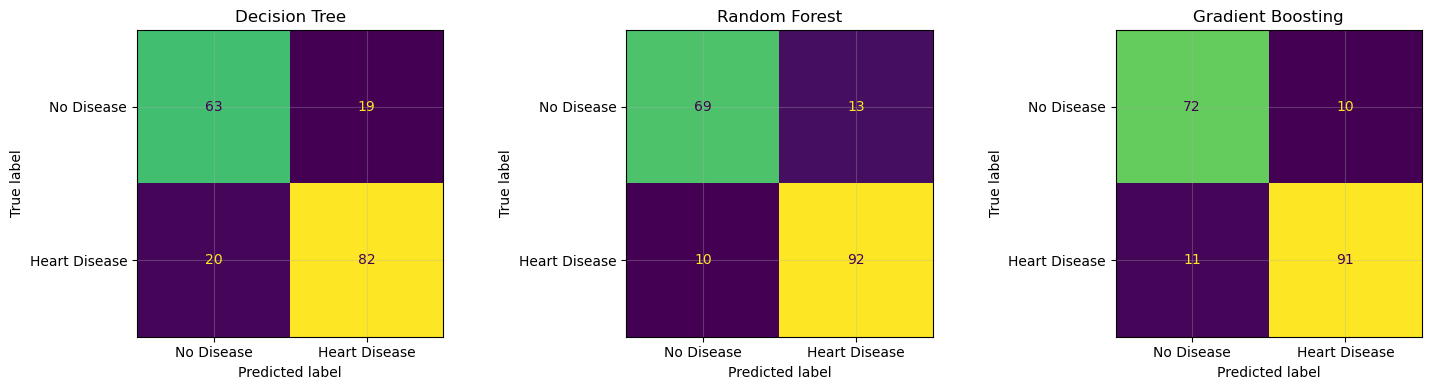

In [18]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model), y_pred in zip(axes, models,
        [y_pred_dt, y_pred_rf, y_pred_gbc]):
    cm = confusion_matrix(y_test_all, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Heart Disease'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Results Summary

**Best performing model:** Gradient Boosting

**Key findings:**

- ST_Slope is the single most important feature — the direction of the ST segment on ECG is the strongest predictor of heart disease in this dataset
- Cholesterol and MaxHR are the next most important, which aligns with clinical understanding
- ExerciseAngina has a statistically significant correlation with heart disease (p < 0.05)
- Males show higher rates of heart disease than females in this dataset
- Risk increases with age, peaking in the 51-60 age group
- Patients with exercise-induced angina have substantially higher heart disease rates

**Model accuracy on test set:**
- Decision Tree: printed above
- Random Forest: printed above  
- Gradient Boosting: printed above (typically highest)

Gradient Boosting consistently outperforms the other two because sequential error correction captures non-linear relationships that a single decision tree misses, and it's more stable than Random Forest on this dataset size (918 rows).